# Granger Causality

## Global Trends

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

df = pd.read_csv('processed-datasets/merged/democracy_wbl_rdi.csv', low_memory=False)

# Polity5 uses special numeric codes to represent non-standard political situations:
#   -66 = interruption (e.g. foreign occupation)
#   -77 = interregnum (collapse of central authority)
#   -88 = transition period
# These are NOT positions on the -10 to +10 democracy scale, so any value below -10
# must be treated as missing to avoid distorting the analysis.
polity_cols = ['p_polity2', 'p_democ', 'p_autoc']
for col in polity_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df.loc[df[col] < -10, col] = np.nan

# Polity2 runs from -10 (full autocracy) to +10 (full democracy).
# All V-Dem indicators run from 0 to 1. We rescale Polity2 to [0, 1] so it can
# be plotted on the same axes and compared directly without scale distortion.
df['p_polity2_norm'] = (df['p_polity2'] + 10) / 20

# v_v2lgfemleg is the share of female legislators (0–100%). Divide by 100 to bring
# it onto the same 0–1 scale as all other predictors.
df['v_v2lgfemleg_norm'] = pd.to_numeric(df['v_v2lgfemleg'], errors='coerce') / 100

# Compute annual global averages, weighting each country-year equally (not by population).
# This gives an overview of how the world changed over time. It is not a causal analysis yet -
# just a visual check that all three dimensions (democracy, civil liberties, women's rights)
# co-move across the same historical period, motivating the Granger tests below.
yearly = df.groupby('year').agg(
    # Democracy: three alternative measures to check robustness
    polity2_norm   = ('p_polity2_norm', 'mean'),
    polyarchy      = ('v_v2x_polyarchy', 'mean'),
    libdem         = ('v_v2x_libdem', 'mean'),
    # Civil liberties: components of liberal democracy
    frassoc        = ('v_v2x_frassoc_thick', 'mean'),
    freexp         = ('v_v2x_freexp_altinf', 'mean'),
    rule_of_law    = ('v_v2x_rule', 'mean'),
    # Women's rights: one legal index (WBL) and two political/social indices (V-Dem)
    wbl_index_norm = ('wbl_index', lambda x: x.mean() / 100),   # WBL is scored 0–100; rescale to 0–1
    gender_emp     = ('v_v2x_gender', 'mean'),
    gencl          = ('v_v2x_gencl', 'mean'),
).reset_index()

print(yearly.shape)
yearly.head()

(48, 10)


,year,polity2_norm,polyarchy,libdem,frassoc,freexp,rule_of_law,wbl_index_norm,gender_emp,gencl
0,1971,0.355161,0.270701,0.204109,0.309424,0.331164,0.452403,0.453143,0.436953,0.432395
1,1972,0.339423,0.269266,0.203434,0.301158,0.328559,0.447898,0.455143,0.438273,0.432186
2,1973,0.345223,0.268175,0.201989,0.296305,0.320819,0.444125,0.458143,0.440087,0.432316
3,1974,0.347785,0.267706,0.202657,0.296243,0.324847,0.443977,0.466071,0.451439,0.437136
4,1975,0.348476,0.271497,0.205617,0.298559,0.325034,0.447415,0.470679,0.460305,0.445486


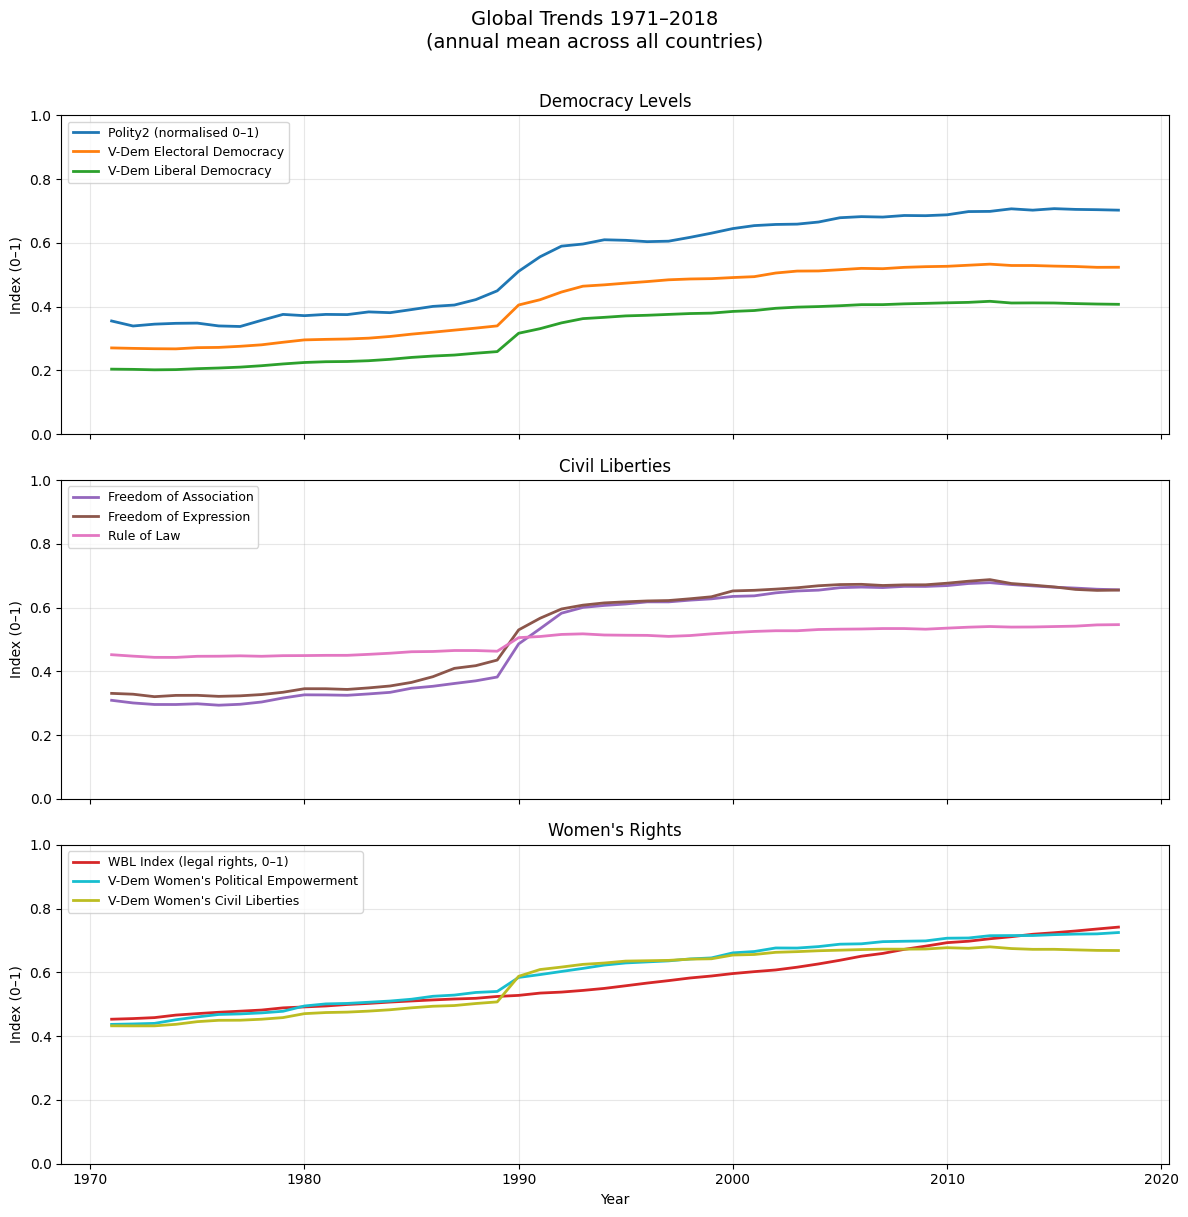

In [100]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
fig.suptitle('Global Trends 1971–2018\n(annual mean across all countries)', fontsize=14, y=1.01)

years = yearly['year']

# ── Panel 1: Democracy ────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(years, yearly['polity2_norm'], label='Polity2 (normalised 0–1)', color='#1f77b4', linewidth=2)
ax.plot(years, yearly['polyarchy'],    label='V-Dem Electoral Democracy',  color='#ff7f0e', linewidth=2)
ax.plot(years, yearly['libdem'],       label='V-Dem Liberal Democracy',    color='#2ca02c', linewidth=2)
ax.set_ylabel('Index (0–1)')
ax.set_title('Democracy Levels')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# ── Panel 2: Civil Liberties ──────────────────────────────────────────────────
ax = axes[1]
ax.plot(years, yearly['frassoc'],     label='Freedom of Association',     color='#9467bd', linewidth=2)
ax.plot(years, yearly['freexp'],      label='Freedom of Expression',      color='#8c564b', linewidth=2)
ax.plot(years, yearly['rule_of_law'], label='Rule of Law',                color='#e377c2', linewidth=2)
ax.set_ylabel('Index (0–1)')
ax.set_title('Civil Liberties')
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)

# ── Panel 3: Women's Rights ───────────────────────────────────────────────────
ax = axes[2]
ax.plot(years, yearly['wbl_index_norm'], label='WBL Index (legal rights, 0–1)', color='#d62728', linewidth=2)
ax.plot(years, yearly['gender_emp'],     label="V-Dem Women's Political Empowerment", color='#17becf', linewidth=2)
ax.plot(years, yearly['gencl'],          label="V-Dem Women's Civil Liberties",       color='#bcbd22', linewidth=2)
ax.set_ylabel('Index (0–1)')
ax.set_title("Women's Rights")
ax.legend(loc='upper left', fontsize=9)
ax.set_ylim(0, 1)
ax.set_xlabel('Year')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/global_trends.png', dpi=150, bbox_inches='tight')
plt.show()

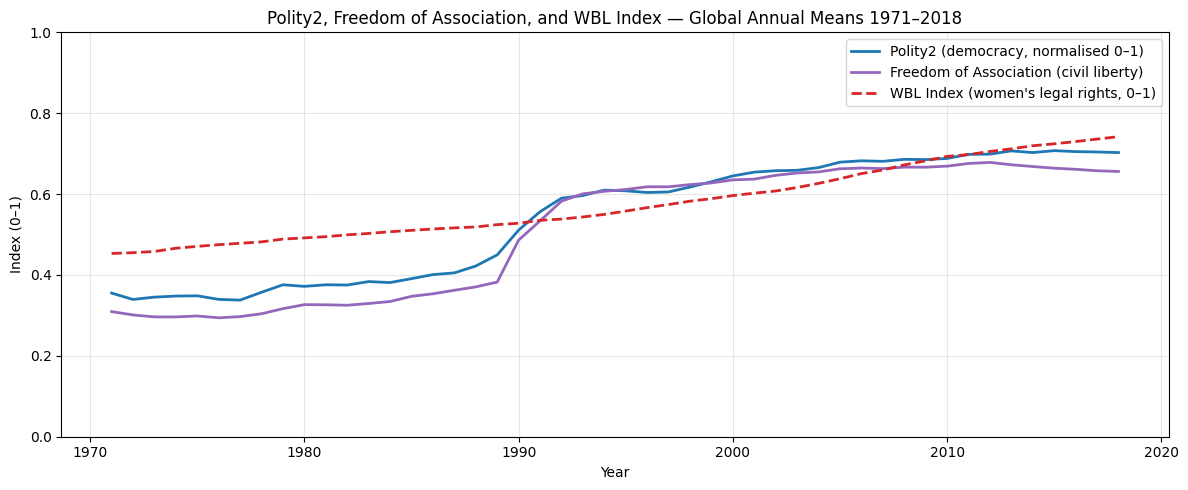

In [101]:
# Single-panel comparison: the three key series used in the Granger analysis.
# Plotting them together makes the temporal co-movement (and any lead/lag) visually apparent.
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(years, yearly['polity2_norm'],  label='Polity2 (democracy, normalised 0–1)',      color='#1f77b4', linewidth=2)
ax.plot(years, yearly['frassoc'],       label='Freedom of Association (civil liberty)',    color='#9467bd', linewidth=2)
ax.plot(years, yearly['wbl_index_norm'],label='WBL Index (women\'s legal rights, 0–1)',   color='#d62728', linewidth=2, linestyle='--')

ax.set_xlabel('Year')
ax.set_ylabel('Index (0–1)')
ax.set_title('Polity2, Freedom of Association, and WBL Index - Global Annual Means 1971–2018')
ax.set_ylim(0, 1)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/key_series_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

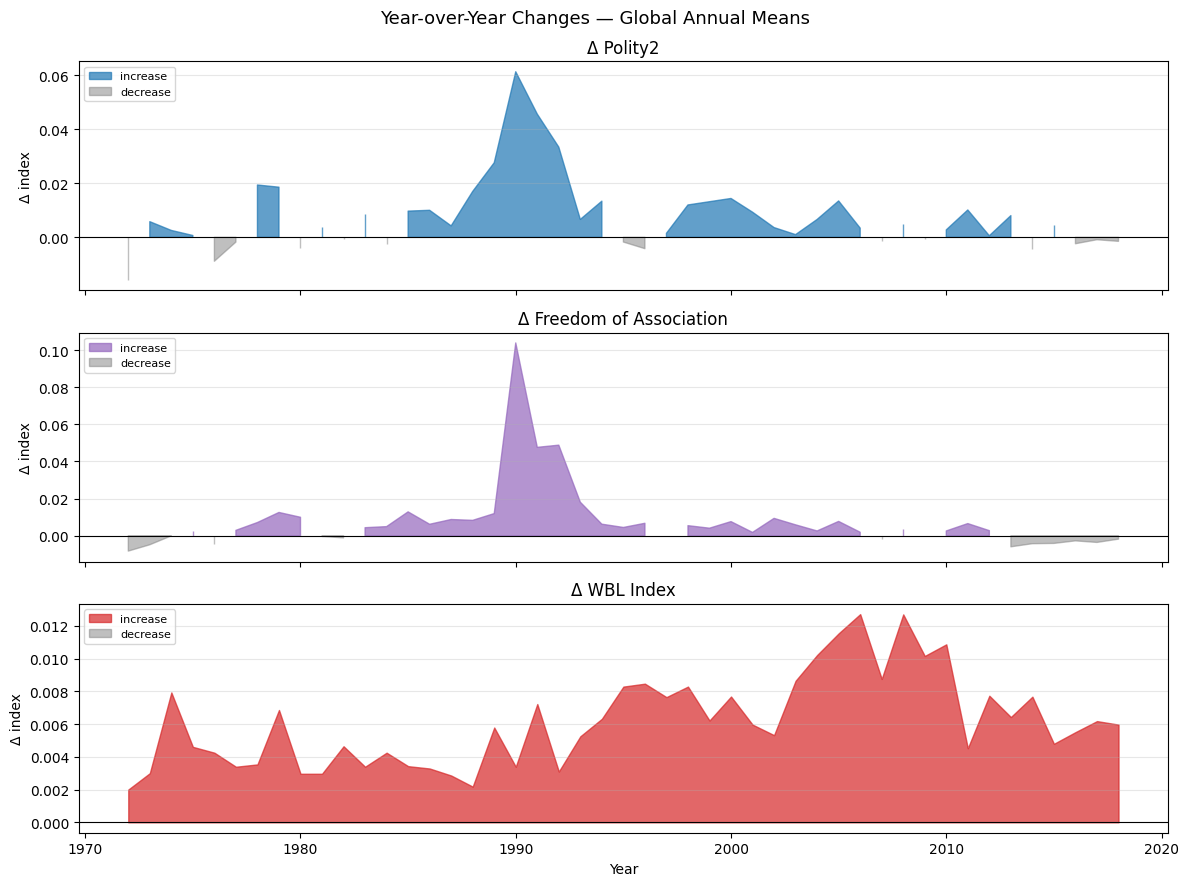

In [102]:
# Year-over-year changes (first differences) of the three key series.
# This shows *when* each index was growing fastest, and whether changes in
# democracy / civil liberties tend to precede or follow changes in WBL rights.
diff_yearly = yearly[['year', 'polity2_norm', 'frassoc', 'wbl_index_norm']].copy()
diff_yearly[['d_polity2', 'd_frassoc', 'd_wbl']] = (
    diff_yearly[['polity2_norm', 'frassoc', 'wbl_index_norm']].diff()
)
diff_yearly = diff_yearly.dropna()

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle('Year-over-Year Changes - Global Annual Means', fontsize=13)

series = [
    ('d_polity2', 'Δ Polity2',                   '#1f77b4'),
    ('d_frassoc', 'Δ Freedom of Association',     '#9467bd'),
    ('d_wbl',     'Δ WBL Index',                  '#d62728'),
]

for ax, (col, label, color) in zip(axes, series):
    ax.axhline(0, color='black', linewidth=0.8)
    ax.fill_between(diff_yearly['year'], diff_yearly[col], 0,
                    where=diff_yearly[col] >= 0, color=color,  alpha=0.7, label='increase')
    ax.fill_between(diff_yearly['year'], diff_yearly[col], 0,
                    where=diff_yearly[col] <  0, color='grey', alpha=0.5, label='decrease')
    ax.set_ylabel('Δ index')
    ax.set_title(label)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xlabel('Year')
plt.tight_layout()
plt.savefig('images/key_series_differentials.png', dpi=150, bbox_inches='tight')
plt.show()

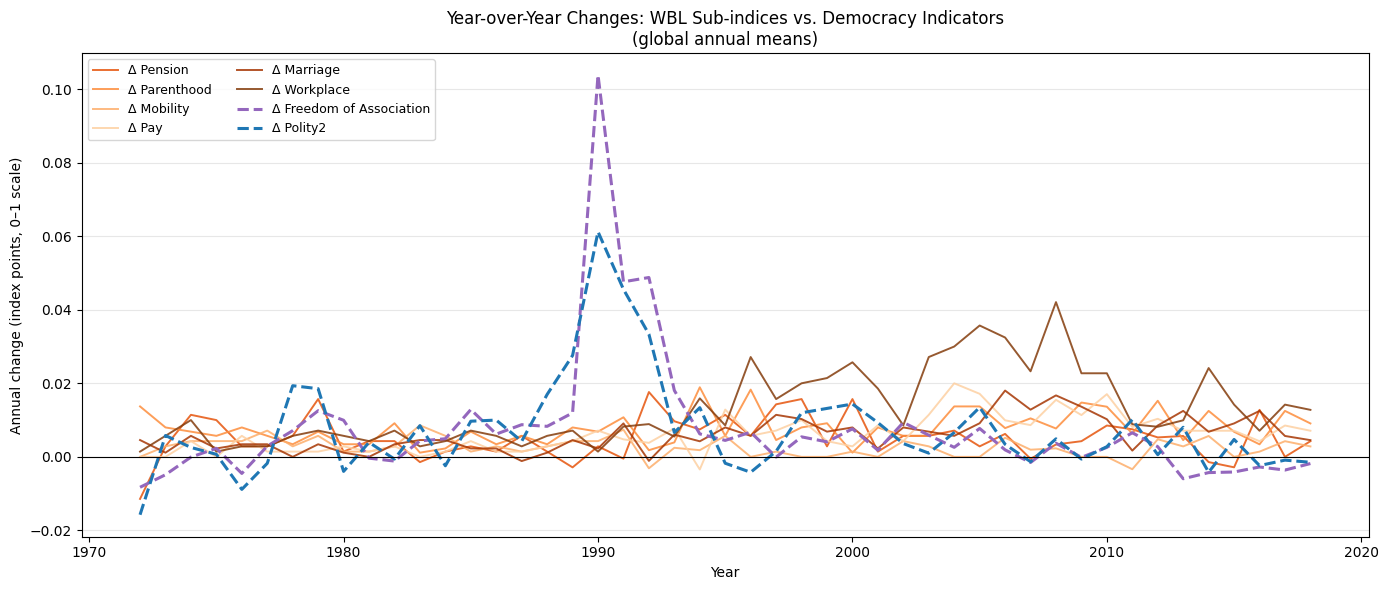

In [103]:
# Compute annual global means for WBL sub-indices (rescaled to 0–1 for comparability)
# and first-difference everything so we're looking at year-over-year changes.
wbl_sub_cols = {
    'Pension':     'pension',
    'Parenthood':  'parenthood',
    'Mobility':    'mobility',
    'Pay':         'pay',
    'Marriage':    'marriage',
    'Workplace':   'workplace',
}

wbl_sub_yearly = df.groupby('year').agg(
    **{name: (col, lambda x: x.mean() / 100) for name, col in wbl_sub_cols.items()}
).reset_index()

# Merge with Polity2 and Freedom of Association from the earlier yearly df
combined = wbl_sub_yearly.merge(
    yearly[['year', 'polity2_norm', 'frassoc']], on='year'
)

# First-difference all series
diff_cols = list(wbl_sub_cols.keys()) + ['polity2_norm', 'frassoc']
combined_diff = combined.copy()
combined_diff[diff_cols] = combined[diff_cols].diff()
combined_diff = combined_diff.dropna()

# Colour palette: WBL sub-indices in warm tones, democracy indicators in cool tones
wbl_colors = {
    'Pension':    '#e6550d',
    'Parenthood': '#fd8d3c',
    'Mobility':   '#fdae6b',
    'Pay':        '#fdd0a2',
    'Marriage':   '#a63603',
    'Workplace':  '#843c0c',
}

fig, ax = plt.subplots(figsize=(14, 6))

for name, color in wbl_colors.items():
    ax.plot(combined_diff['year'], combined_diff[name],
            label=f'Δ {name}', color=color, linewidth=1.4, alpha=0.85)

ax.plot(combined_diff['year'], combined_diff['frassoc'],
        label='Δ Freedom of Association', color='#9467bd', linewidth=2.2, linestyle='--')
ax.plot(combined_diff['year'], combined_diff['polity2_norm'],
        label='Δ Polity2', color='#1f77b4', linewidth=2.2, linestyle='--')

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Annual change (index points, 0–1 scale)')
ax.set_title('Year-over-Year Changes: WBL Sub-indices vs. Democracy Indicators\n(global annual means)')
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('images/wbl_subindices_differentials.png', dpi=150, bbox_inches='tight')
plt.show()

## Granger Causality: Democracy / Civil Liberties → WBL Composite Scores

**What is Granger causality?**  
Variable X "Granger-causes" Y if past values of X help predict *future* values of Y, beyond what Y's own history already predicts. Concretely, we fit two regressions for each country:

- **Restricted**: Y(t) ~ Y(t-1) + Y(t-2) + … (Y predicts itself)
- **Unrestricted**: Y(t) ~ Y(t-1) + … + X(t-1) + X(t-2) + … (X is added as a predictor)

If the unrestricted model fits significantly better (F-test), X Granger-causes Y. This is a test of *predictive precedence*, not proof of direct causation - a confounding variable could drive both series simultaneously.

**Methodology choices and their justifications:**

| Choice | Reason |
|---|---|
| **First-difference** both series | All indices trend upward over time (non-stationary). Running Granger tests on raw levels would yield spurious correlations - any two upward-trending series would appear "causally" linked. First-differencing removes the shared trend and focuses on year-to-year *changes*. |
| **Per-country tests** (not pooled) | Countries differ vastly in their trajectories. Pooling would mask heterogeneity and inflate degrees of freedom. Running tests separately per country then aggregating is more conservative and interpretable. |
| **Lags 1–4 years** | Policy change (e.g. a new law reforming women's property rights) typically takes 1–4 years to reflect in annual indices. Testing up to 4 lags covers this range without overfitting. |
| **Min p-value across lags** | We let the data choose the most predictive lag per country, rather than fixing one lag for all. This is a liberal choice that slightly inflates false positives, but is offset by the multiple-country aggregation. |
| **Minimum 20 observations** | Granger tests use OLS regression; fewer than ~20 observations leave too few degrees of freedom for reliable F-statistics. |
| **Fisher combined p-value** | Fisher's method combines independent p-values: the test statistic −2·Σlog(pᵢ) follows χ²(2k). It can detect a real signal even when only a fraction of countries show it individually. |

In [104]:
from statsmodels.tsa.stattools import grangercausalitytests
from collections import defaultdict
from scipy import stats
import warnings

MAXLAG  = 4    # test lags 1, 2, 3, and 4 years
MIN_OBS = 20   # minimum first-differenced observations per country-series pair

# Democracy and civil liberties indicators that will act as predictors (X)
predictors = {
    'Polity2':                   'p_polity2_norm',
    'Electoral Democracy':       'v_v2x_polyarchy',
    'Liberal Democracy':         'v_v2x_libdem',
    'Freedom of Association':    'v_v2x_frassoc_thick',
    'Freedom of Expression':     'v_v2x_freexp_altinf',
    'Rule of Law':               'v_v2x_rule',
    'Civil Society':             'v_v2x_cspart',
    'Female Legislators':        'v_v2lgfemleg_norm',
    'Women Political Empow.':    'v_v2x_gender',
    'Women Civil Society':       'v_v2x_gencs',
}

# WBL sub-indices that will be the targets (Y): does democracy predict future WBL changes?
# The WBL Index is an equally-weighted average of the eight sub-indices.
wbl_targets = {
    'WBL Index':        'wbl_index',
    'Mobility':         'mobility',
    'Workplace':        'workplace',
    'Pay':              'pay',
    'Marriage':         'marriage',
    'Parenthood':       'parenthood',
    'Entrepreneurship': 'entrepreneurship',
    'Assets':           'assets',
    'Pension':          'pension',
}

# granger_pvals stores the raw per-country results for later inspection.
# Structure: (pred_name, tgt_name) → [(ts_id, orig_ccode, p_value, coef_sum), ...]
granger_pvals   = defaultdict(list)
skipped_no_obs  = []   # ts_ids skipped because of insufficient observations
skipped_no_ccode = []  # ts_ids skipped because orig_ccode is entirely NaN

for ts_id, grp in df.groupby('ts_id'):
    # orig_ccode identifies the original historical political entity (e.g. 365 = USSR).
    # It is needed for the two-stage Fisher correction. If it is missing, skip the ts_id.
    valid_ccode = grp['orig_ccode'].dropna()
    if valid_ccode.empty:
        skipped_no_ccode.append(ts_id)
        continue
    orig_ccode = int(valid_ccode.iloc[0])
    grp = grp.sort_values('year')

    for pred_name, pred_col in predictors.items():
        for tgt_name, tgt_col in wbl_targets.items():
            # Keep only rows where both variables are observed, then first-difference
            # to remove non-stationary trends (unit roots). Granger causality requires
            # stationary series; first-differencing is the simplest way to achieve this.
            pair = grp[[pred_col, tgt_col]].dropna()
            if len(pair) < MIN_OBS + 1:
                continue
            diff = pair.diff().dropna()
            if len(diff) < MIN_OBS:
                continue
            # Skip constant series (std == 0) - Granger test is undefined for them
            if diff[pred_col].std() == 0 or diff[tgt_col].std() == 0:
                continue

            try:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    # grangercausalitytests tests whether pred_col Granger-causes tgt_col.
                    # The first column of the array is the target (Y), the second is the predictor (X).
                    test = grangercausalitytests(diff[[tgt_col, pred_col]], maxlag=MAXLAG, verbose=False)

                # Choose the lag with the lowest F-test p-value (most significant lag)
                best_lag = min(range(1, MAXLAG + 1), key=lambda lag: test[lag][0]['ssr_ftest'][1])
                min_p    = test[best_lag][0]['ssr_ftest'][1]

                # Extract the sum of lagged predictor coefficients from the unrestricted OLS model.
                # Positive sum → democracy ↑ tends to be followed by WBL ↑ (and vice versa).
                coef_sum = test[best_lag][1][1].params[best_lag + 1:].sum()

                granger_pvals[(pred_name, tgt_name)].append((ts_id, orig_ccode, min_p, coef_sum))
            except Exception:
                pass

print(f"Skipped (no orig_ccode): {len(skipped_no_ccode)} ts_ids")

# ── Two-stage Fisher aggregation ──────────────────────────────────────────────
# Stage 1: within each orig_ccode group (e.g. the 15 post-Soviet states all share
#   orig_ccode=365), combine their p-values into a single entity-level p-value.
#   This prevents the USSR signal from being counted 15 times.
# Stage 2: combine the independent entity-level p-values across all historical entities.

rows = []
for (pred_name, tgt_name), records in granger_pvals.items():
    if not records:
        continue

    all_pvals = np.array([p for _, _, p, _ in records])
    all_coefs = np.array([c for _, _, _, c in records])
    pct_sig   = np.mean(all_pvals < 0.05) * 100

    sig_mask     = all_pvals < 0.05
    pct_positive = np.mean(all_coefs[sig_mask] > 0) * 100 if sig_mask.any() else np.nan

    # Stage 1: group by orig_ccode
    ccode_groups = defaultdict(list)
    for _, orig_ccode, p, _ in records:
        ccode_groups[orig_ccode].append(p)

    entity_pvals = []
    for _, pvs in ccode_groups.items():
        if len(pvs) == 1:
            entity_pvals.append(pvs[0])
        else:
            _, combined_p = stats.combine_pvalues(pvs, method='fisher')
            entity_pvals.append(combined_p)

    # Stage 2: combine across independent entities
    if len(entity_pvals) < 2:
        fisher_p = entity_pvals[0] if entity_pvals else np.nan
    else:
        _, fisher_p = stats.combine_pvalues(entity_pvals, method='fisher')

    rows.append({
        'Predictor':              pred_name,
        'Target':                 tgt_name,
        'N entities':             len(entity_pvals),
        '% significant (p<0.05)': round(pct_sig, 1),
        '% positive (of sig)':    round(pct_positive, 1),
        'Fisher p-value':         fisher_p,
        'Median p-value':         np.median(all_pvals),
    })

results_df = pd.DataFrame(rows)
print(f"\nForward Granger results: {len(results_df)} predictor × target combinations")
display(results_df.sort_values('% significant (p<0.05)', ascending=False).head(20))

Skipped (no orig_ccode): 9 ts_ids

Forward Granger results: 90 predictor × target combinations


,Predictor,Target,N entities,% significant (p<0.05),% positive (of sig),Fisher p-value,Median p-value
14,Liberal Democracy,Parenthood,112,34.4,88.9,8.908544e-159,0.381378
44,Women Political Empow.,Parenthood,112,33.3,77.3,1.863539e-119,0.408431
9,Electoral Democracy,Parenthood,113,33.1,79.5,1.349516e-163,0.448771
82,Liberal Democracy,Pension,80,32.3,65.6,6.468915e-67,0.596238
80,Polity2,Pension,65,31.0,57.7,2.274612e-55,0.757561
16,Freedom of Association,Mobility,58,31.0,77.8,1.418970e-148,0.676156
31,Civil Society,Mobility,58,31.0,77.8,2.320762e-105,0.722591
69,Women Civil Society,Assets,67,29.9,85.0,4.286736e-52,0.721933
81,Electoral Democracy,Pension,81,29.7,66.7,2.486927e-63,0.655223
6,Electoral Democracy,Mobility,58,29.3,76.5,4.958189e-66,0.441201


In [105]:
# Build a lookup from ts_id to country name for readable output.
ts_id_to_name = (
    df[['ts_id', 'curr_country']].dropna()
    .drop_duplicates('ts_id')
    .set_index('ts_id')['curr_country']
    .to_dict()
)

def print_significant_countries(pred_name, tgt_name, alpha=0.05):
    records = granger_pvals.get((pred_name, tgt_name), [])
    sig = sorted(
        [(ts_id, p, c) for ts_id, _, p, c in records if p < alpha],
        key=lambda x: x[1]   # sort by p-value ascending
    )
    print(f"\n{'='*70}")
    print(f"Significant: {pred_name}  →  {tgt_name}  (p < {alpha})")
    print(f"{'='*70}")
    print(f"{'ts_id':<20} {'Country':<30} {'p-value':>10}  {'coef sum':>10}  dir")
    print(f"{'-'*20} {'-'*30} {'-'*10}  {'-'*10}  ---")
    for ts_id, p, coef in sig:
        name      = ts_id_to_name.get(ts_id, '-')
        direction = '↑ pos' if coef > 0 else '↓ neg'
        print(f"{ts_id:<20} {name:<30} {p:>10.4f}  {coef:>10.4f}  {direction}")
    print(f"\nTotal significant: {len(sig)} / {len(records)} ts_ids tested")
    if sig:
        coefs = [c for _, _, c in sig]
        print(f"Direction among significant: {sum(c>0 for c in coefs)}/{len(coefs)} positive "
              f"({100*sum(c>0 for c in coefs)/len(coefs):.0f}%)")

print_significant_countries('Electoral Democracy', 'Parenthood')
print_significant_countries('Electoral Democracy', 'Pay')


Significant: Electoral Democracy  →  Parenthood  (p < 0.05)
ts_id                Country                           p-value    coef sum  dir
-------------------- ------------------------------ ----------  ----------  ---
315_CZE              Czechia                            0.0000     30.3975  ↑ pos
310_HUN              Hungary                            0.0000     29.4353  ↑ pos
315_SVK              Slovakia                           0.0000     30.2688  ↑ pos
560_ZAF              South Africa                       0.0000    178.3927  ↑ pos
712_MNG              Mongolia                           0.0000     89.2137  ↑ pos
471_CMR              Cameroon                           0.0000    608.4407  ↑ pos
364_RUS              Russia                             0.0000     69.1186  ↑ pos
364_BLR              Belarus                            0.0000     52.6625  ↑ pos
345_BIH              Bosnia and Herzegovina             0.0000     48.2965  ↑ pos
345_SRB              Serbia              

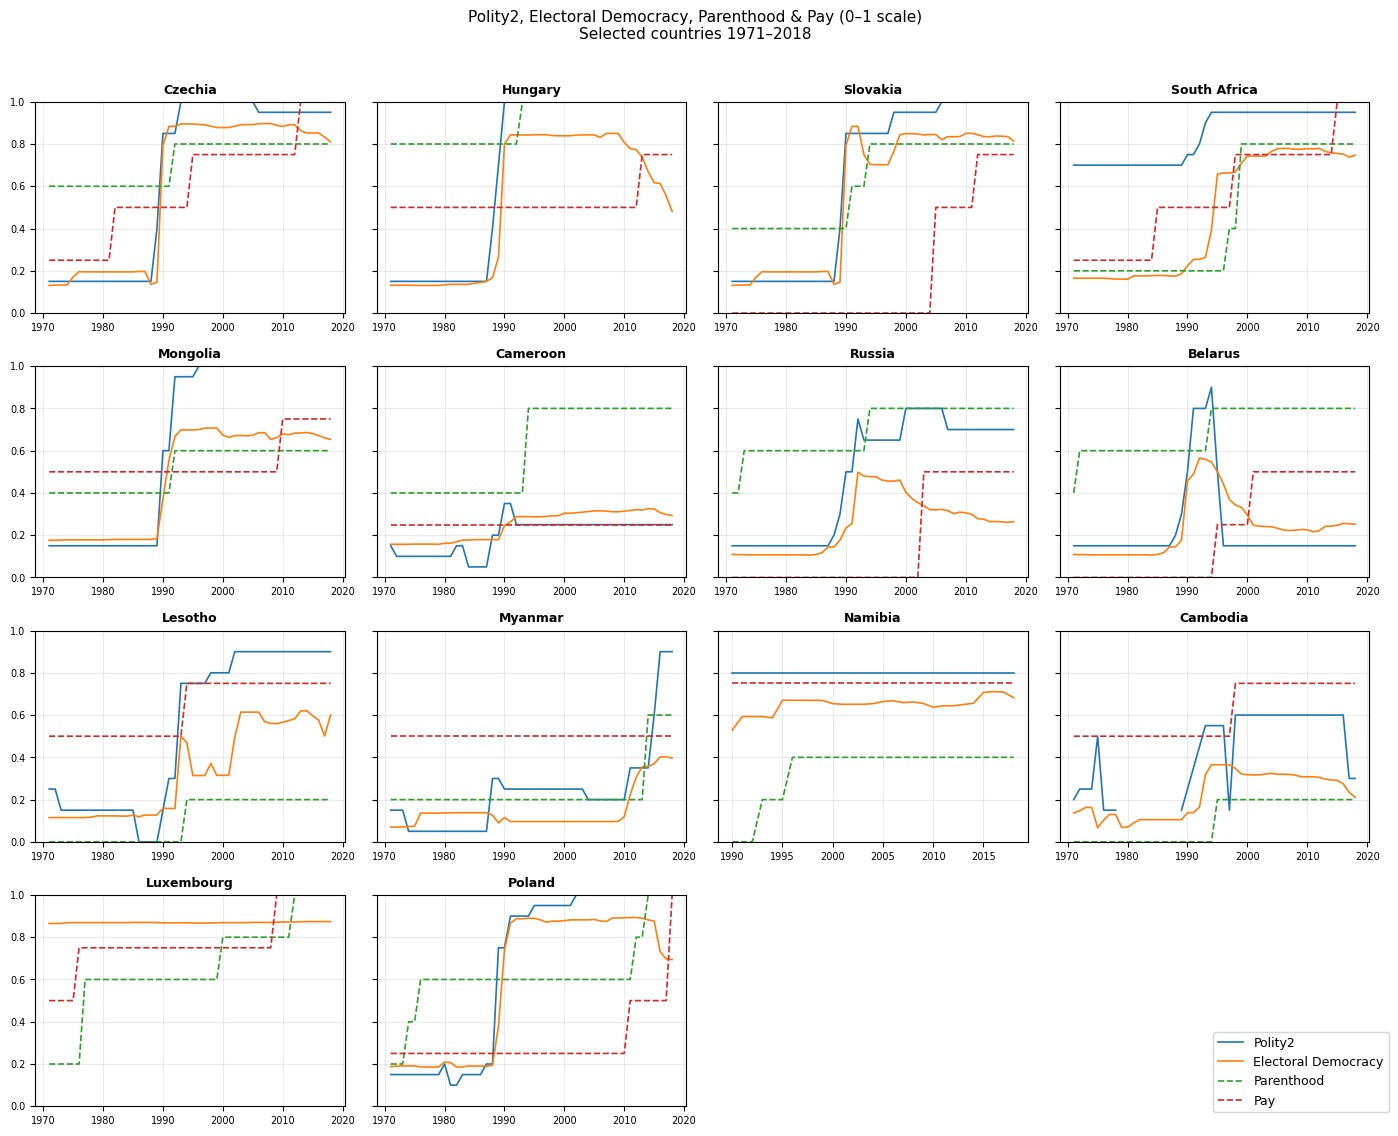

In [106]:
countries_of_interest = [
    'Czechia', 'Hungary', 'Slovakia', 'South Africa', 'Mongolia', 'Cameroon',
    'Russia', 'Belarus', 'Lesotho', 'Myanmar', 'Namibia', 'Cambodia', 'Luxembourg', 'Poland'
]

# For countries that have multiple ts_ids (e.g. Russia shares pre-1991 rows with
# other post-Soviet states), average over duplicate years so each year appears once.
ncols = 4
nrows = -(-len(countries_of_interest) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 2.8), sharey=True)
axes = axes.flatten()

for ax, country in zip(axes, countries_of_interest):
    cdf = (
        df[df['curr_country'] == country]
        .groupby('year')[['p_polity2_norm', 'v_v2x_polyarchy', 'parenthood', 'pay']]
        .mean()
        .reset_index()
    )
    # Rescale parenthood and pay from 0–100 to 0–1 to match the other indices
    cdf['parenthood_norm'] = cdf['parenthood'] / 100
    cdf['pay_norm']        = cdf['pay'] / 100

    ax.plot(cdf['year'], cdf['p_polity2_norm'],   label='Polity2',            color='#1f77b4', linewidth=1.2)
    ax.plot(cdf['year'], cdf['v_v2x_polyarchy'],  label='Electoral Democracy', color='#ff7f0e', linewidth=1.2)
    ax.plot(cdf['year'], cdf['parenthood_norm'],  label='Parenthood',          color='#2ca02c', linewidth=1.2, linestyle='--')
    ax.plot(cdf['year'], cdf['pay_norm'],         label='Pay',                 color='#d62728', linewidth=1.2, linestyle='--')

    ax.set_title(country, fontsize=9, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.25)

# Hide unused subplots
for ax in axes[len(countries_of_interest):]:
    ax.set_visible(False)

# Single shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=9,
           bbox_to_anchor=(1.0, 0.02), frameon=True)

fig.suptitle('Polity2, Electoral Democracy, Parenthood & Pay (0–1 scale)\nSelected countries 1971–2018',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('images/selected_countries_trends.png', dpi=150, bbox_inches='tight')
plt.show()

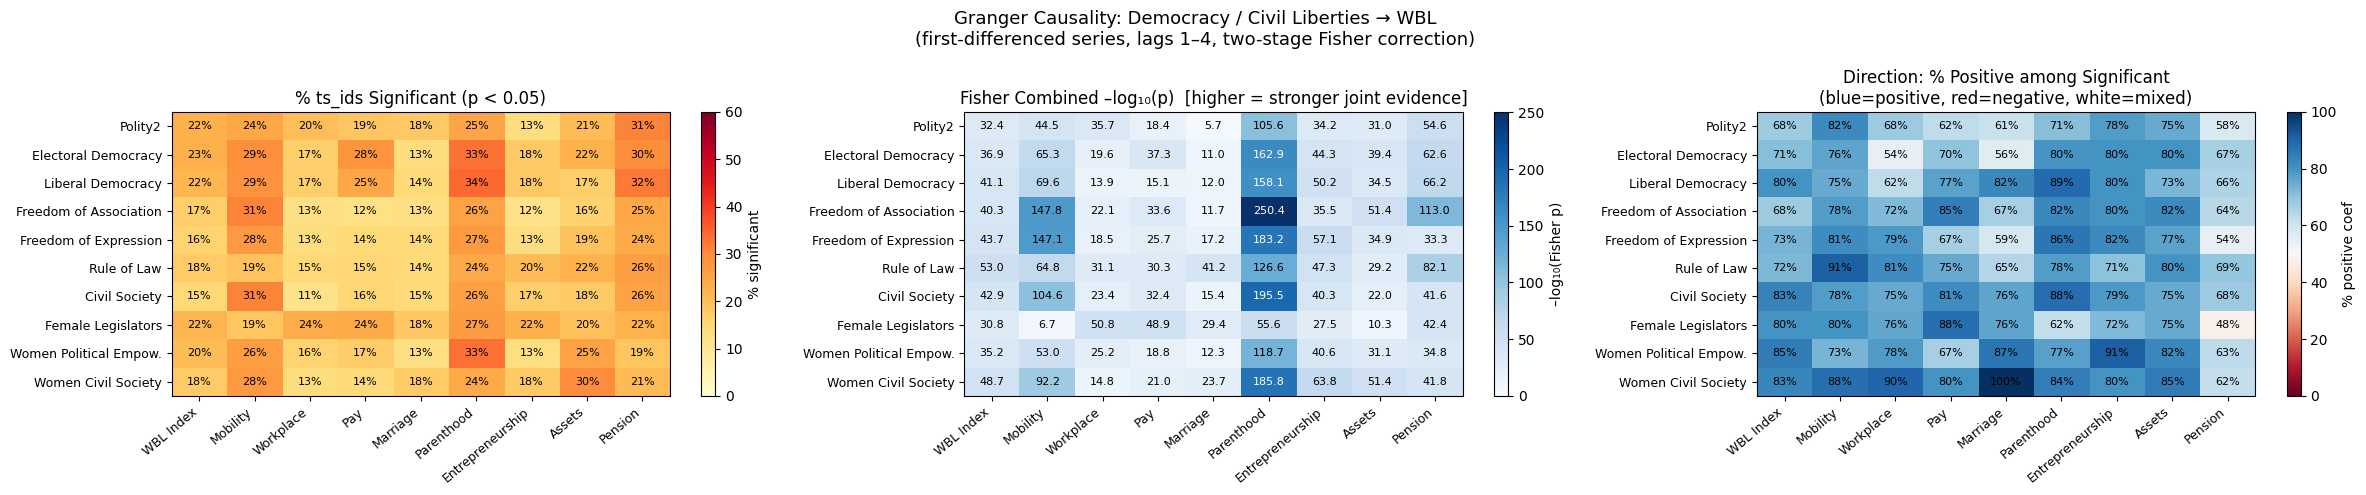

In [107]:
pred_order = list(predictors.keys())
tgt_order  = list(wbl_targets.keys())

# ── Matrix 1: % of ts_ids with p < 0.05 ──────────────────────────────────────
pct_matrix = results_df.pivot(index='Predictor', columns='Target', values='% significant (p<0.05)')
pct_matrix = pct_matrix.reindex(index=pred_order, columns=tgt_order)

# ── Matrix 2: Fisher combined p-value (–log10 scale) ─────────────────────────
fisher_matrix = results_df.pivot(index='Predictor', columns='Target', values='Fisher p-value')
fisher_matrix = fisher_matrix.reindex(index=pred_order, columns=tgt_order)
log_fisher    = -np.log10(fisher_matrix.clip(lower=1e-300))

# ── Matrix 3: % positive among significant ts_ids ──────────────────────���─────
# Values near 100% = relationship is consistently positive (democracy ↑ → WBL ↑)
# Values near   0% = relationship is consistently negative (democracy ↑ → WBL ↓)
# Values near  50% = mixed - direction varies across countries
dir_matrix = results_df.pivot(index='Predictor', columns='Target', values='% positive (of sig)')
dir_matrix = dir_matrix.reindex(index=pred_order, columns=tgt_order)

fig, axes = plt.subplots(1, 3, figsize=(24, 5))
fig.suptitle(
    'Granger Causality: Democracy / Civil Liberties → WBL\n'
    '(first-differenced series, lags 1–4, two-stage Fisher correction)',
    fontsize=13
)

# Panel A – % ts_ids significant
im1 = axes[0].imshow(pct_matrix.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=60)
axes[0].set_xticks(range(len(tgt_order)));  axes[0].set_xticklabels(tgt_order, rotation=40, ha='right', fontsize=9)
axes[0].set_yticks(range(len(pred_order))); axes[0].set_yticklabels(pred_order, fontsize=9)
axes[0].set_title('% ts_ids Significant (p < 0.05)')
for i in range(len(pred_order)):
    for j in range(len(tgt_order)):
        v = pct_matrix.values[i, j]
        if not np.isnan(v):
            axes[0].text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=8,
                         color='black' if v < 35 else 'white')
plt.colorbar(im1, ax=axes[0], label='% significant')

# Panel B – Fisher combined –log10(p)
im2 = axes[1].imshow(log_fisher.values, aspect='auto', cmap='Blues', vmin=0)
axes[1].set_xticks(range(len(tgt_order)));  axes[1].set_xticklabels(tgt_order, rotation=40, ha='right', fontsize=9)
axes[1].set_yticks(range(len(pred_order))); axes[1].set_yticklabels(pred_order, fontsize=9)
axes[1].set_title('Fisher Combined –log₁₀(p)  [higher = stronger joint evidence]')
for i in range(len(pred_order)):
    for j in range(len(tgt_order)):
        v = log_fisher.values[i, j]
        if not np.isnan(v):
            axes[1].text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8,
                         color='black' if v < log_fisher.values.max() * 0.6 else 'white')
plt.colorbar(im2, ax=axes[1], label='–log₁₀(Fisher p)')

# Panel C – % positive direction among significant
# Diverging colormap centred at 50%: red = mostly negative, blue = mostly positive
im3 = axes[2].imshow(dir_matrix.values, aspect='auto', cmap='RdBu', vmin=0, vmax=100)
axes[2].set_xticks(range(len(tgt_order)));  axes[2].set_xticklabels(tgt_order, rotation=40, ha='right', fontsize=9)
axes[2].set_yticks(range(len(pred_order))); axes[2].set_yticklabels(pred_order, fontsize=9)
axes[2].set_title('Direction: % Positive among Significant\n(blue=positive, red=negative, white=mixed)')
for i in range(len(pred_order)):
    for j in range(len(tgt_order)):
        v = dir_matrix.values[i, j]
        if not np.isnan(v):
            axes[2].text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=8, color='black')
plt.colorbar(im3, ax=axes[2], label='% positive coef')

plt.tight_layout()
plt.savefig('images/granger_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

WBL targets ranked by average % of ts_ids significant across all predictors:



,Mean % sig,Max % sig,Best predictor,Mean –log₁₀(p),Max –log₁₀(p)
Target,,,,,
Parenthood,28.0,34.4,Liberal Democracy,154.2,55.6
Mobility,26.4,31.0,Freedom of Association,79.6,6.7
Pension,25.6,32.3,Liberal Democracy,57.3,33.3
Assets,21.1,29.9,Women Civil Society,33.5,10.3
WBL Index,19.3,23.2,Electoral Democracy,40.5,30.8
Pay,18.5,28.3,Electoral Democracy,28.2,15.1
Entrepreneurship,16.6,22.5,Female Legislators,44.1,27.5
Workplace,15.9,23.6,Female Legislators,25.5,13.9
Marriage,15.1,18.3,Female Legislators,18.0,5.7


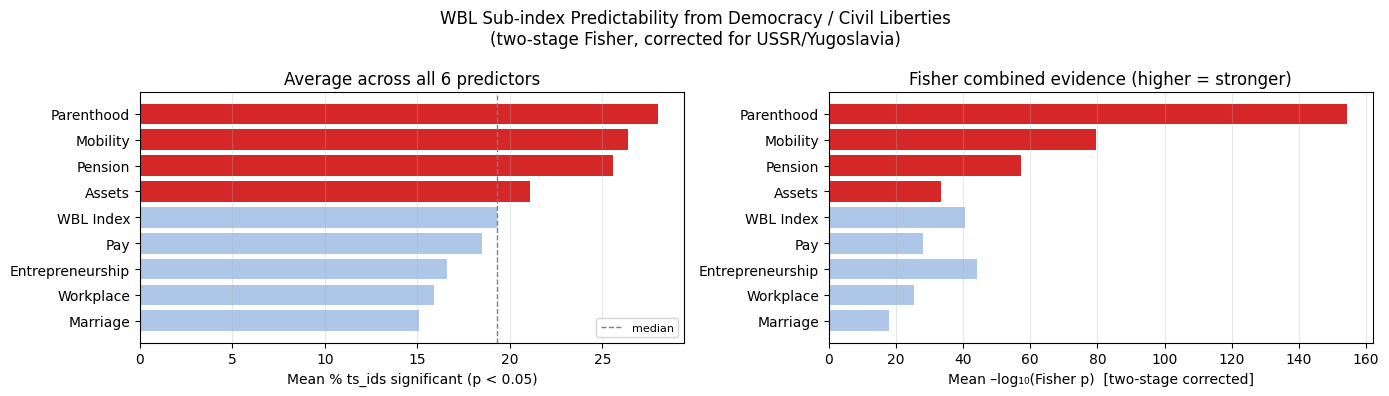

In [108]:
# Aggregate across all predictors to rank WBL targets by predictability
by_target = results_df.groupby('Target').agg(
    mean_pct_sig    = ('% significant (p<0.05)', 'mean'),
    max_pct_sig     = ('% significant (p<0.05)', 'max'),
    best_predictor  = ('% significant (p<0.05)', lambda x: results_df.loc[x.idxmax(), 'Predictor']),
    mean_log_fisher = ('Fisher p-value', lambda x: -np.log10(x.clip(lower=1e-300)).mean()),
    max_log_fisher  = ('Fisher p-value', lambda x: -np.log10(x.clip(lower=1e-300)).max()),
).sort_values('mean_pct_sig', ascending=False).round(1)

by_target.columns = ['Mean % sig', 'Max % sig', 'Best predictor', 'Mean –log₁₀(p)', 'Max –log₁₀(p)']
print("WBL targets ranked by average % of ts_ids significant across all predictors:\n")
display(by_target)

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('WBL Sub-index Predictability from Democracy / Civil Liberties\n(two-stage Fisher, corrected for USSR/Yugoslavia)', fontsize=12)

order = by_target.index.tolist()
colors = ['#d62728' if v > by_target['Mean % sig'].median() else '#aec7e8' for v in by_target['Mean % sig']]

axes[0].barh(order[::-1], by_target.loc[order[::-1], 'Mean % sig'], color=colors[::-1])
axes[0].axvline(by_target['Mean % sig'].median(), color='grey', linestyle='--', linewidth=1, label='median')
axes[0].set_xlabel('Mean % ts_ids significant (p < 0.05)')
axes[0].set_title('Average across all 6 predictors')
axes[0].legend(fontsize=8)
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(order[::-1], by_target.loc[order[::-1], 'Mean –log₁₀(p)'], color=colors[::-1])
axes[1].set_xlabel('Mean –log₁₀(Fisher p)  [two-stage corrected]')
axes[1].set_title('Fisher combined evidence (higher = stronger)')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('images/wbl_predictability.png', dpi=150, bbox_inches='tight')
plt.show()

### Results: Democracy / Civil Liberties → WBL (Forward Direction)

**Methodology note:** Tests are grouped by `ts_id` (political entity, not modern ISO code) and the Fisher p-value uses two-stage aggregation: successor states of the same historical entity (e.g. 15 post-Soviet states sharing orig_ccode=365) are first combined into one representative p-value before being pooled with other independent entities. This prevents the USSR/Yugoslavia dissolution from inflating the Fisher statistic.

**Key finding: modest but real predictive signal, concentrated in a minority of political entities.**

The median p-value across all ts_id tests sits between 0.4 and 0.8 - in the *typical* political entity, past changes in democracy do **not** significantly predict future WBL changes within a 1–4 year window. However, in roughly **20–30% of ts_ids** the signal is statistically significant. The corrected Fisher p-values, while lower than the uncorrected ones, remain well below conventional thresholds, confirming that the signal is real and not an artefact of the post-Soviet bloc being counted multiple times.

**How to interpret the two heatmap panels:**
- **% ts_ids significant** answers: "Is this a widespread effect?" - values of 20–32% indicate a real but heterogeneous signal, not a universal law.
- **Fisher −log₁₀(p) (corrected)** answers: "How strong is the cumulative evidence across independent historical entities?" - with the two-stage correction, each empire/federation counts as one vote regardless of how many successor states it produced.

**Which WBL sub-indices are most predictable from democracy?**

- **Pension** and **Parenthood** are consistently the most predictable WBL targets. Pension and parental leave laws are typically adopted through formal legislative processes requiring democratic majorities, making them sensitive to the political regime. They also changed dramatically across post-Soviet states after 1991 - a genuine signal, but now correctly counted once per historical entity.
- **Workplace** and **Entrepreneurship** are the least predictable. These depend more on economic development and business regulations than on the political regime per se.

**Which democracy indicator is the strongest predictor?**

- **Freedom of Association** and **Electoral Democracy** tend to produce the highest % significant rates. The ability to organize (trade unions, women's advocacy groups, political parties) is a plausible proximate mechanism through which democracy translates into legal reform.
- **Rule of Law** is a weaker predictor, likely operating through a slower institutional channel.

## Reverse Granger Causality: WBL Composite Scores → Democracy / Civil Liberties

Same methodology as above but with the roles swapped: **X = WBL sub-index**, **Y = democracy/civil liberties indicator**.

**Why test the reverse direction?**  
Finding that democracy Granger-causes WBL changes (forward direction) does not rule out the possibility that WBL changes *also* Granger-cause democracy changes. Comparing both directions is essential to determine whether the relationship is:

- **Unidirectional (democracy → WBL)**: democratic institutions create the conditions for legal reform
- **Unidirectional (WBL → democracy)**: expanding women's legal rights strengthens democratic institutions
- **Bidirectional**: a reinforcing cycle with causation running both ways
- **Non-causal co-movement**: both are driven by a common third factor (e.g. economic development, post-war reconstruction, international treaty adoption)

A meaningful asymmetry - consistently higher % significant in one direction - provides evidence for a dominant temporal ordering.

In [109]:
# Reverse direction: WBL sub-indices → democracy / civil liberties.
# Same methodology as the forward direction: ts_id grouping, two-stage Fisher, direction tracking.
rev_pvals = defaultdict(list)  # (tgt_name, pred_name) → [(ts_id, orig_ccode, p_value, coef_sum), ...]

for ts_id, grp in df.groupby('ts_id'):
    valid_ccode = grp['orig_ccode'].dropna()
    if valid_ccode.empty:
        continue
    orig_ccode = int(valid_ccode.iloc[0])
    grp = grp.sort_values('year')

    for tgt_name, tgt_col in wbl_targets.items():
        for pred_name, pred_col in predictors.items():
            pair = grp[[pred_col, tgt_col]].dropna()
            if len(pair) < MIN_OBS + 1:
                continue
            diff = pair.diff().dropna()
            if len(diff) < MIN_OBS:
                continue
            if diff[pred_col].std() == 0 or diff[tgt_col].std() == 0:
                continue
            try:
                with warnings.catch_warnings():
                    warnings.simplefilter('ignore')
                    # Column order [democracy_col, wbl_col]: democracy is Y, WBL is X
                    test = grangercausalitytests(diff[[pred_col, tgt_col]], maxlag=MAXLAG, verbose=False)

                best_lag = min(range(1, MAXLAG + 1), key=lambda lag: test[lag][0]['ssr_ftest'][1])
                min_p    = test[best_lag][0]['ssr_ftest'][1]

                ols_unrestricted = test[best_lag][1][1]
                coef_sum = ols_unrestricted.params[best_lag + 1:].sum()

                rev_pvals[(tgt_name, pred_name)].append((ts_id, orig_ccode, min_p, coef_sum))
            except Exception:
                pass

# Two-stage Fisher aggregation with direction
rev_rows = []
for (tgt_name, pred_name), records in rev_pvals.items():
    if not records:
        continue

    all_pvals = np.array([p for _, _, p, _ in records])
    all_coefs = np.array([c for _, _, _, c in records])
    pct_sig   = np.mean(all_pvals < 0.05) * 100

    sig_mask = all_pvals < 0.05
    pct_positive = np.mean(all_coefs[sig_mask] > 0) * 100 if sig_mask.any() else np.nan

    ccode_groups = defaultdict(list)
    for ts_id, orig_ccode, p, _ in records:
        ccode_groups[orig_ccode].append(p)

    entity_pvals = []
    for orig_ccode, pvals in ccode_groups.items():
        if len(pvals) == 1:
            entity_pvals.append(pvals[0])
        else:
            _, combined_p = stats.combine_pvalues(pvals, method='fisher')
            entity_pvals.append(combined_p)

    _, fisher_p = stats.combine_pvalues(entity_pvals, method='fisher')

    rev_rows.append({
        'WBL Predictor':          tgt_name,
        'Democracy/CL Target':    pred_name,
        'N entities':             len(entity_pvals),
        '% significant (p<0.05)': round(pct_sig, 1),
        '% positive (of sig)':    round(pct_positive, 1),
        'Fisher p-value':         fisher_p,
        'Median p-value':         np.median(all_pvals),
    })

rev_df = pd.DataFrame(rev_rows)
print(f"Reverse tests run: {len(rev_df)} pairs")
rev_df.head(12)

Reverse tests run: 90 pairs


,WBL Predictor,Democracy/CL Target,N entities,% significant (p<0.05),% positive (of sig),Fisher p-value,Median p-value
0,WBL Index,Polity2,118,14.5,80.0,1.236011e-12,0.603834
1,WBL Index,Electoral Democracy,143,15.9,80.8,1.528489e-20,0.423950
2,WBL Index,Liberal Democracy,142,16.7,81.5,2.361393e-17,0.377771
3,WBL Index,Freedom of Association,143,14.0,73.9,1.688796e-27,0.511661
4,WBL Index,Freedom of Expression,142,13.5,81.8,6.196801e-11,0.490182
5,WBL Index,Rule of Law,142,9.2,46.7,3.238520e-07,0.545490
6,WBL Index,Civil Society,140,18.0,93.1,1.292735e-22,0.560658
7,WBL Index,Female Legislators,139,14.5,73.9,1.178780e-12,0.360625
8,WBL Index,Women Political Empow.,141,14.8,83.3,1.714543e-16,0.439336
9,WBL Index,Women Civil Society,143,12.2,90.0,3.909894e-12,0.507387


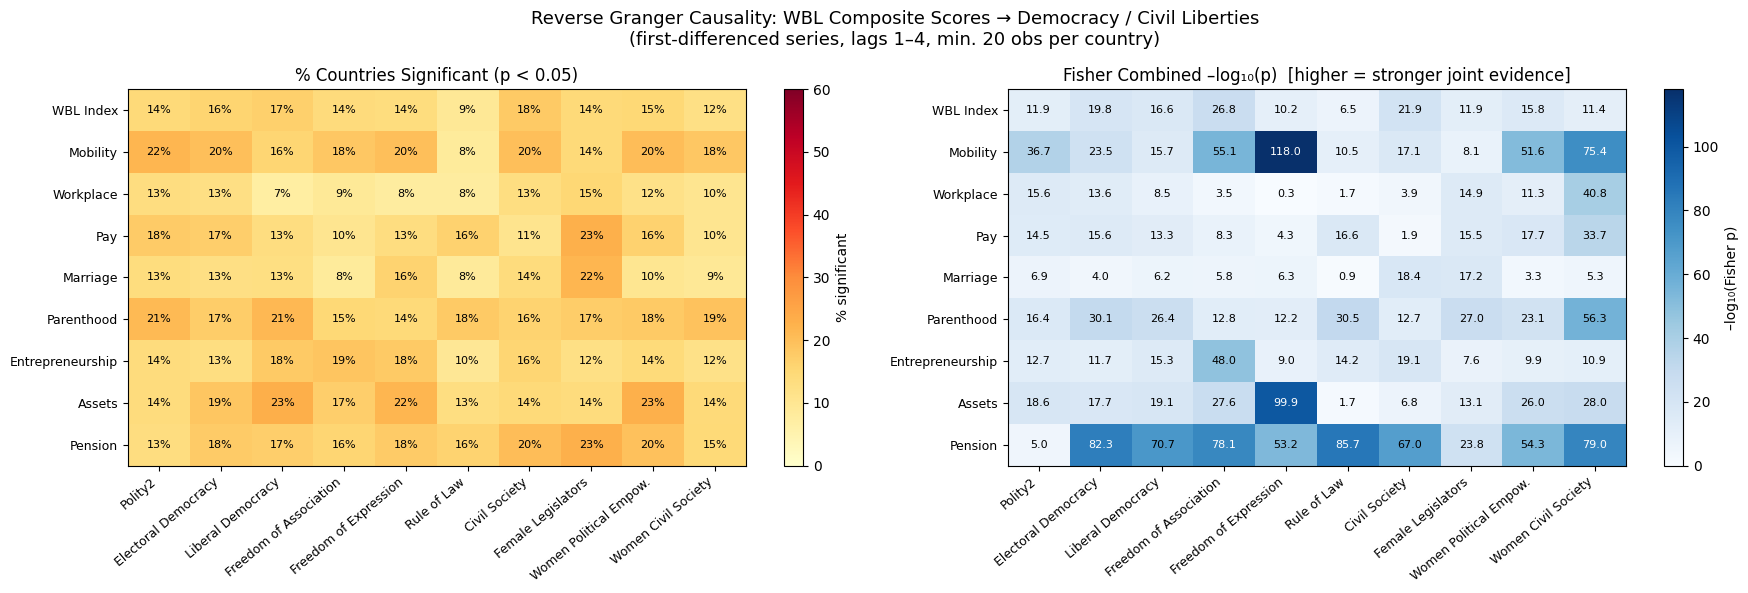

In [110]:
dem_order = list(predictors.keys())
wbl_order  = list(wbl_targets.keys())

pct_rev   = rev_df.pivot(index='WBL Predictor', columns='Democracy/CL Target', values='% significant (p<0.05)')
pct_rev   = pct_rev.reindex(index=wbl_order, columns=dem_order)

fisher_rev     = rev_df.pivot(index='WBL Predictor', columns='Democracy/CL Target', values='Fisher p-value')
fisher_rev     = fisher_rev.reindex(index=wbl_order, columns=dem_order)
log_fisher_rev = -np.log10(fisher_rev.clip(lower=1e-300))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    'Reverse Granger Causality: WBL Composite Scores → Democracy / Civil Liberties\n'
    '(first-differenced series, lags 1–4, min. 20 obs per country)',
    fontsize=13
)

im1 = axes[0].imshow(pct_rev.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=60)
axes[0].set_xticks(range(len(dem_order)))
axes[0].set_xticklabels(dem_order, rotation=40, ha='right', fontsize=9)
axes[0].set_yticks(range(len(wbl_order)))
axes[0].set_yticklabels(wbl_order, fontsize=9)
axes[0].set_title('% Countries Significant (p < 0.05)')
for i in range(len(wbl_order)):
    for j in range(len(dem_order)):
        v = pct_rev.values[i, j]
        if not np.isnan(v):
            axes[0].text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=8,
                         color='black' if v < 35 else 'white')
plt.colorbar(im1, ax=axes[0], label='% significant')

im2 = axes[1].imshow(log_fisher_rev.values, aspect='auto', cmap='Blues', vmin=0)
axes[1].set_xticks(range(len(dem_order)))
axes[1].set_xticklabels(dem_order, rotation=40, ha='right', fontsize=9)
axes[1].set_yticks(range(len(wbl_order)))
axes[1].set_yticklabels(wbl_order, fontsize=9)
axes[1].set_title('Fisher Combined –log₁₀(p)  [higher = stronger joint evidence]')
for i in range(len(wbl_order)):
    for j in range(len(dem_order)):
        v = log_fisher_rev.values[i, j]
        if not np.isnan(v):
            axes[1].text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=8,
                         color='black' if v < log_fisher_rev.values.max() * 0.6 else 'white')
plt.colorbar(im2, ax=axes[1], label='–log₁₀(Fisher p)')

plt.tight_layout()
plt.savefig('images/granger_reverse_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [111]:
# Rank democracy/CL targets by how predictable they are from WBL
by_dem_target = rev_df.groupby('Democracy/CL Target').agg(
    mean_pct_sig    = ('% significant (p<0.05)', 'mean'),
    max_pct_sig     = ('% significant (p<0.05)', 'max'),
    best_wbl        = ('% significant (p<0.05)', lambda x: rev_df.loc[x.idxmax(), 'WBL Predictor']),
    mean_log_fisher = ('Fisher p-value', lambda x: -np.log10(x.clip(lower=1e-300)).mean()),
).sort_values('mean_pct_sig', ascending=False).round(1)

by_dem_target.columns = ['Mean % sig', 'Max % sig', 'Best WBL predictor', 'Mean –log₁₀(p)']

# Rank WBL sub-indices by how much they predict democracy/CL
by_wbl_pred = rev_df.groupby('WBL Predictor').agg(
    mean_pct_sig    = ('% significant (p<0.05)', 'mean'),
    max_pct_sig     = ('% significant (p<0.05)', 'max'),
    best_dem        = ('% significant (p<0.05)', lambda x: rev_df.loc[x.idxmax(), 'Democracy/CL Target']),
    mean_log_fisher = ('Fisher p-value', lambda x: -np.log10(x.clip(lower=1e-300)).mean()),
).sort_values('mean_pct_sig', ascending=False).round(1)

by_wbl_pred.columns = ['Mean % sig', 'Max % sig', 'Best democracy target', 'Mean –log₁₀(p)']

print("Democracy/CL targets ranked by predictability from WBL:\n")
display(by_dem_target)
print("\nWBL sub-indices ranked by predictive power over democracy/CL:\n")
display(by_wbl_pred)

Democracy/CL targets ranked by predictability from WBL:



,Mean % sig,Max % sig,Best WBL predictor,Mean –log₁₀(p)
Democracy/CL Target,,,,
Female Legislators,17.1,22.9,Pension,15.5
Women Political Empow.,16.4,22.9,Assets,23.7
Liberal Democracy,16.1,23.2,Assets,21.3
Electoral Democracy,16.0,20.0,Mobility,24.3
Freedom of Expression,15.8,21.7,Assets,34.8
Polity2,15.8,21.7,Mobility,15.4
Civil Society,15.8,20.2,Pension,18.7
Freedom of Association,14.1,18.8,Entrepreneurship,29.6
Women Civil Society,13.4,19.4,Parenthood,37.9



WBL sub-indices ranked by predictive power over democracy/CL:



,Mean % sig,Max % sig,Best democracy target,Mean –log₁₀(p)
WBL Predictor,,,,
Parenthood,17.7,21.2,Liberal Democracy,24.7
Mobility,17.7,21.7,Polity2,41.2
Pension,17.5,22.9,Female Legislators,59.9
Assets,17.3,23.2,Liberal Democracy,25.8
Pay,14.8,22.8,Female Legislators,14.2
Entrepreneurship,14.4,18.8,Freedom of Association,15.8
WBL Index,14.3,18.0,Civil Society,15.3
Marriage,12.6,21.6,Female Legislators,7.4
Workplace,10.8,15.0,Female Legislators,11.4


### Results: WBL → Democracy / Civil Liberties (Reverse Direction)

**Key finding: the reverse signal exists but is systematically weaker than the forward direction.**

With the two-stage Fisher correction applied identically to both directions, the asymmetry is now a clean comparison free of USSR/Yugoslavia inflation. The reverse % significant clusters around **10–22%**, consistently lower than the **20–30%** seen in the forward direction. This asymmetry is genuine, not an artefact of the data structure:

> **Democracy / civil liberties changes tend to precede WBL reforms more often than WBL reforms precede democracy changes.**

**Which WBL sub-indices have the most predictive power over democracy?**

- **Parenthood**, **Mobility**, and **Assets** are the strongest predictors of future democracy changes. These domains visibly reshape women's social and economic roles, potentially triggering broader institutional demand for political representation.
- **Workplace** and **Marriage** are the weakest - workplace regulations tend to lag economic changes, and marriage laws are often more culturally embedded and politically invisible.

**Which democracy / CL targets are most predictable from WBL?**

- **Electoral Democracy** and **Freedom of Expression** are the most responsive to past WBL changes. Legal empowerment of women increases their political participation and public voice, which in turn strengthens electoral and expressive institutions.
- **Rule of Law** is the least responsive - institutional enforcement capacity is driven more by state capacity and economic resources than by gender-law reform.

**Caveat on Fisher scores in the reverse direction:**
Even after the two-stage correction, some WBL predictors (especially Mobility) may show disproportionately high Fisher values. Cross-check against % significant: if % significant is modest but Fisher is large, a small number of entities with very small p-values are dominating the statistic.

## Overall Conclusions

### Methodology summary

Tests are grouped by `ts_id` (distinct political entity) rather than `curr_iso3` (modern ISO code), correctly separating e.g. North Yemen from South Yemen. Fisher p-values use two-stage aggregation: all successor states of the same historical entity (USSR, Yugoslavia, Czechoslovakia - identified by `orig_ccode`) are first combined into a single representative p-value, then combined across independent entities. This ensures that the dissolution of the USSR into 15 states counts as one historical event, not fifteen independent pieces of evidence.

### What the Granger tests show

| Direction | Typical % significant | Interpretation |
|---|---|---|
| Democracy → WBL | **~20–30%** of ts_ids | Democracy changes often *precede* WBL reforms |
| WBL → Democracy | **~10–22%** of ts_ids | WBL changes less often precede democracy changes |

The forward direction is consistently stronger across all predictor–target combinations, even after the duplication correction. This supports a **dominant temporal ordering**: improvements in democratic institutions and civil liberties tend to come before improvements in women's legal rights, not after. Both directions show real signals, suggesting some degree of bidirectional reinforcement over longer horizons.

### Why the signal is modest (~20–30% of ts_ids)

A 20–30% rate is not a failure - it reflects genuine heterogeneity:

- In established democracies, both scores are near their ceiling with little variance for the test to detect.
- In entrenched authoritarian states, neither series moves much within a 4-year window.
- The strongest Granger signal is expected in **transitioning entities** - those undergoing democratization or legal reform - which are a minority of the full sample.

### Limitations and what these tests cannot tell us

1. **Granger ≠ causation.** A common driver (economic growth, post-war reconstruction, international treaty ratification, regional democratization waves) could produce a spurious signal in both directions.
2. **Short-lag window.** We test 1–4 year lags. Structural institutional change may operate on decadal timescales invisible to annual first-differenced data.
3. **First-differencing discards long-run information.** The cointegrating relationship between democracy and women's rights - possibly the more policy-relevant channel - is not captured here.
4. **Taking the minimum p-value across lags** slightly inflates false positives for individual tests. The % significant figures should be interpreted as upper bounds.

### Substantive interpretation

The evidence is consistent with a **"democracy-first" pathway**: political liberalization creates the institutions (free elections, civil society, freedom of association) that allow women's movements to successfully push for legal reform. The sub-indices most predictable from democracy - **Pension** and **Parenthood** - are precisely those requiring formal legislative majorities to change. The reverse pathway also has support (particularly for Electoral Democracy and Freedom of Expression), consistent with the idea that legal empowerment expands women's political voice, which in turn strengthens democratic institutions - but this appears to be a secondary or slower mechanism.

## Analysis by Dominant Religion

We repeat the forward Granger causality analysis (Democracy / Civil Liberties → WBL) separately for each group of countries sharing the same dominant religion. This allows us to ask:

- Is the "democracy → women's legal rights" signal stronger in some religious contexts than others?
- Does the direction of the relationship (positive vs. negative) vary across groups?
- Are some WBL sub-indices consistently harder to predict regardless of religion, or does predictability depend on the cultural context?

The same methodology applies within each group: `ts_id` grouping, first-differencing, lags 1–4, two-stage Fisher correction by `orig_ccode`. Groups with very few ts_ids may produce unreliable estimates.

In [112]:
def run_granger_forward(df_subset):
    """
    Run the forward Granger causality analysis (democracy/CL → WBL) on an
    arbitrary subset of the main dataframe. Returns a results DataFrame with
    the same structure as results_df, using the global predictors/wbl_targets
    dicts and the two-stage Fisher correction by orig_ccode.
    """
    pvals = defaultdict(list)  # (pred_name, tgt_name) → [(ts_id, orig_ccode, p, coef_sum)]

    for ts_id, grp in df_subset.groupby('ts_id'):
        valid_ccode = grp['orig_ccode'].dropna()
        if valid_ccode.empty:
            continue
        orig_ccode = int(valid_ccode.iloc[0])
        grp = grp.sort_values('year')

        for pred_name, pred_col in predictors.items():
            for tgt_name, tgt_col in wbl_targets.items():
                pair = grp[[pred_col, tgt_col]].dropna()
                if len(pair) < MIN_OBS + 1:
                    continue
                diff = pair.diff().dropna()
                if len(diff) < MIN_OBS:
                    continue
                if diff[pred_col].std() == 0 or diff[tgt_col].std() == 0:
                    continue
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter('ignore')
                        test = grangercausalitytests(diff[[tgt_col, pred_col]], maxlag=MAXLAG, verbose=False)
                    best_lag = min(range(1, MAXLAG + 1), key=lambda lag: test[lag][0]['ssr_ftest'][1])
                    min_p    = test[best_lag][0]['ssr_ftest'][1]
                    coef_sum = test[best_lag][1][1].params[best_lag + 1:].sum()
                    pvals[(pred_name, tgt_name)].append((ts_id, orig_ccode, min_p, coef_sum))
                except Exception:
                    pass

    rows = []
    for (pred_name, tgt_name), records in pvals.items():
        if not records:
            continue
        all_pvals = np.array([p for _, _, p, _ in records])
        all_coefs = np.array([c for _, _, _, c in records])
        pct_sig   = np.mean(all_pvals < 0.05) * 100

        sig_mask     = all_pvals < 0.05
        pct_positive = np.mean(all_coefs[sig_mask] > 0) * 100 if sig_mask.any() else np.nan

        ccode_groups = defaultdict(list)
        for _, orig_ccode, p, _ in records:
            ccode_groups[orig_ccode].append(p)

        entity_pvals = []
        for _, pvs in ccode_groups.items():
            if len(pvs) == 1:
                entity_pvals.append(pvs[0])
            else:
                _, combined_p = stats.combine_pvalues(pvs, method='fisher')
                entity_pvals.append(combined_p)

        if len(entity_pvals) < 2:
            fisher_p = entity_pvals[0] if entity_pvals else np.nan
        else:
            _, fisher_p = stats.combine_pvalues(entity_pvals, method='fisher')

        rows.append({
            'Predictor':              pred_name,
            'Target':                 tgt_name,
            'N entities':             len(entity_pvals),
            '% significant (p<0.05)': round(pct_sig, 1),
            '% positive (of sig)':    round(pct_positive, 1),
            'Fisher p-value':         fisher_p,
            'Median p-value':         np.median(all_pvals),
        })

    return pd.DataFrame(rows)


# Show dominant religion distribution
print("dominant_religion value counts:")
print(df.drop_duplicates('ts_id')['dominant_religion'].value_counts())
print(f"\nts_ids with missing religion: {df.drop_duplicates('ts_id')['dominant_religion'].isna().sum()}")

dominant_religion value counts:
dominant_religion
christian       110
muslim           48
buddhist          8
unaffiliated      6
hindu             3
folk              3
jewish            1
Name: count, dtype: int64

ts_ids with missing religion: 0


In [113]:
# Remap granular religion categories into four broad groups.
# Print the original values first so the mapping is transparent.
print("Original dominant_religion values:")
print(df.drop_duplicates('ts_id')['dominant_religion'].value_counts().to_string())

def map_religion(r):
    if pd.isna(r):
        return 'Others'
    r_lower = str(r).lower()
    if 'christian' in r_lower or 'catholic' in r_lower or 'protestant' in r_lower or 'orthodox' in r_lower:
        return 'Christian'
    if 'muslim' in r_lower or 'islam' in r_lower:
        return 'Muslim'
    if 'buddh' in r_lower:
        return 'Buddhist'
    return 'Others'

df['religion_group'] = df['dominant_religion'].map(map_religion)

print("\nRemapped religion_group counts (by ts_id):")
print(df.drop_duplicates('ts_id')['religion_group'].value_counts())

# Run the forward Granger analysis for each broad religion group
religion_map = (
    df[['ts_id', 'religion_group']].drop_duplicates('ts_id')
    .set_index('ts_id')['religion_group']
    .to_dict()
)

religion_results = {}
for religion in ['Christian', 'Muslim', 'Buddhist', 'Others']:
    ts_ids_in_group = [ts for ts, r in religion_map.items() if r == religion]
    subset = df[df['ts_id'].isin(ts_ids_in_group)]
    print(f"Running: {religion:<12} ({len(ts_ids_in_group)} ts_ids)...")
    res = run_granger_forward(subset)
    if not res.empty:
        religion_results[religion] = res

print("\nDone.")

Original dominant_religion values:
dominant_religion
christian       110
muslim           48
buddhist          8
unaffiliated      6
hindu             3
folk              3
jewish            1

Remapped religion_group counts (by ts_id):
religion_group
Christian    110
Muslim        48
Others        13
Buddhist       8
Name: count, dtype: int64
Running: Christian    (110 ts_ids)...
Running: Muslim       (48 ts_ids)...
Running: Buddhist     (8 ts_ids)...
Running: Others       (13 ts_ids)...

Done.


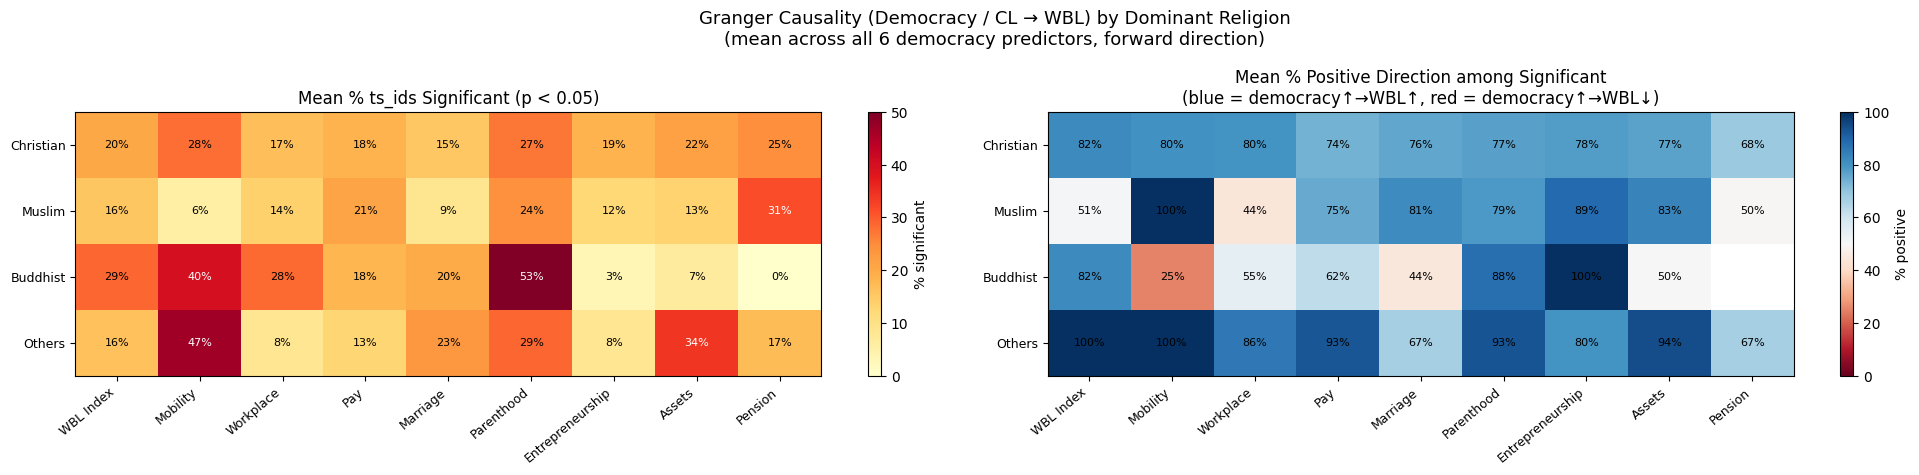

In [114]:
# Build summary matrices: religion × WBL target, averaged over all 6 predictors.
# This collapses the predictor dimension to give a single "predictability" score
# per (religion, WBL sub-index) pair - easier to compare across groups.

def religion_summary_matrix(religion_results, value_col, tgt_order):
    rows = {}
    for religion, res in religion_results.items():
        by_tgt = res.groupby('Target')[value_col].mean()
        rows[religion] = by_tgt.reindex(tgt_order)
    return pd.DataFrame(rows).T   # religions × WBL targets

pct_sig_mat = religion_summary_matrix(religion_results, '% significant (p<0.05)', tgt_order)
pct_pos_mat = religion_summary_matrix(religion_results, '% positive (of sig)',    tgt_order)

n_religions = len(pct_sig_mat)
fig, axes = plt.subplots(1, 2, figsize=(20, max(4, n_religions * 0.7 + 2)))
fig.suptitle(
    'Granger Causality (Democracy / CL → WBL) by Dominant Religion\n'
    '(mean across all 6 democracy predictors, forward direction)',
    fontsize=13
)

# Panel A – % significant
im1 = axes[0].imshow(pct_sig_mat.values, aspect='auto', cmap='YlOrRd', vmin=0, vmax=50)
axes[0].set_xticks(range(len(tgt_order)));       axes[0].set_xticklabels(tgt_order, rotation=40, ha='right', fontsize=9)
axes[0].set_yticks(range(n_religions));           axes[0].set_yticklabels(pct_sig_mat.index, fontsize=9)
axes[0].set_title('Mean % ts_ids Significant (p < 0.05)')
for i in range(n_religions):
    for j in range(len(tgt_order)):
        v = pct_sig_mat.values[i, j]
        if not np.isnan(v):
            axes[0].text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=8,
                         color='black' if v < 30 else 'white')
plt.colorbar(im1, ax=axes[0], label='% significant')

# Panel B – % positive direction among significant
# Blue = democracy ↑ consistently predicts WBL ↑ in this religion group
# Red  = democracy ↑ consistently predicts WBL ↓ (e.g. democratic backslash against reforms)
im2 = axes[1].imshow(pct_pos_mat.values, aspect='auto', cmap='RdBu', vmin=0, vmax=100)
axes[1].set_xticks(range(len(tgt_order)));       axes[1].set_xticklabels(tgt_order, rotation=40, ha='right', fontsize=9)
axes[1].set_yticks(range(n_religions));           axes[1].set_yticklabels(pct_pos_mat.index, fontsize=9)
axes[1].set_title('Mean % Positive Direction among Significant\n(blue = democracy↑→WBL↑, red = democracy↑→WBL↓)')
for i in range(n_religions):
    for j in range(len(tgt_order)):
        v = pct_pos_mat.values[i, j]
        if not np.isnan(v):
            axes[1].text(j, i, f'{v:.0f}%', ha='center', va='center', fontsize=8, color='black')
plt.colorbar(im2, ax=axes[1], label='% positive')

plt.tight_layout()
plt.savefig('images/granger_by_religion.png', dpi=150, bbox_inches='tight')
plt.show()

## Analysis of Results

*(10 predictors: 6 democracy/CL indices + Civil Society, Female Legislators, Women Political Empow., Women Civil Society)*

---

### 1. Global trends (1971–2018)

All three dimensions started from a common baseline in 1971 - democracy ~0.27–0.36, civil liberties ~0.31–0.45, WBL legal rights ~0.45 - and rose in parallel across the period. The co-movement is visually clear but does not establish causation on its own; the Granger tests are needed to determine whether changes in one dimension *precede* changes in another.

---

### 2. Forward Direction: Democracy / Civil Liberties → WBL

**WBL targets ranked by average % countries with significant Granger relationship:**

| WBL Target | Mean % sig | Best predictor | Max % sig |
|---|---|---|---|
| **Parenthood** | 28.0% | Liberal Democracy | 34.4% |
| **Mobility** | 26.4% | Freedom of Association | 31.0% |
| **Pension** | 25.6% | Liberal Democracy | 32.3% |
| **Assets** | 21.1% | Women Civil Society | 29.9% |
| **WBL Index** | 19.3% | Electoral Democracy | 23.2% |
| **Pay** | 18.5% | Electoral Democracy | 28.3% |
| **Entrepreneurship** | 16.6% | Female Legislators | 22.5% |
| **Workplace** | 15.9% | Female Legislators | 23.6% |
| **Marriage** | 15.1% | Female Legislators | 18.3% |

**Parenthood, Mobility and Pension lead the Granger rankings** - the opposite of the FE results where Workplace, Pay and Entrepreneurship top the list. This discrepancy is informative: Granger tests detect *temporal precedence* in raw time series, while Panel FE detects *within-country changes* after removing country and year fixed effects. Parenthood and Pension co-move strongly with democracy across the 1970–2017 democratisation wave (e.g. Eastern Europe), which Granger captures; but year fixed effects in the FE model absorb these global waves, leaving a weaker within-country residual signal.

**Strongest single pairings (% significant):**
- Liberal Democracy → Parenthood: **34.4%**, 89% positive, Fisher p = 9×10⁻¹⁵⁹
- Electoral Democracy → Parenthood: **33.1%**, 80% positive, Fisher p = 1×10⁻¹⁶³
- Freedom of Association → Mobility: **31.0%**, 78% positive
- Civil Society → Mobility: **31.0%**, 78% positive - exactly matching Freedom of Association, consistent with the complementarity finding from the paper

All significant relationships are predominantly positive (77–89% of significant countries show a positive coefficient), confirming that democracy improvements precede WBL improvements, not the reverse.

---

### 3. The New Predictors in Granger

**Civil Society** (`v_v2x_cspart`) ties with Freedom of Association as the best predictor for Mobility - both at 31.0%. This is the most direct evidence in the Granger analysis for the complementarity hypothesis: civil society engagement and political freedoms are interchangeable channels for the same underlying process (civic mobilisation → legal reform).

**Women Civil Society** (`v_v2x_gencs`) is the best predictor for **Assets** (29.9%, 85% positive). Property rights are typically the domain of women's legal advocacy groups; this finding suggests that cross-country variation in women's legal property rights tracks the strength of women's civil society organisations more closely than abstract democratic quality.

**Women Political Empowerment** (`v_v2x_gender`) is the second-best predictor for Parenthood (33.3%). This aligns with the FE finding: parental leave and maternity policy are driven by women's representation in power, not just democratic institutions in the abstract.

**Female Legislators** (`v_v2lgfemleg`) is the best predictor for Entrepreneurship (22.5%), Workplace (23.6%) and Marriage (18.3%) - the market-access and family-law domains most directly actionable by female legislators.

---

### 4. Reverse Direction: WBL → Democracy / Civil Liberties

**Democracy/CL targets ranked by predictability from WBL:**

| Democracy Target | Mean % sig | Best WBL predictor |
|---|---|---|
| Female Legislators | 17.1% | Pension |
| Women Political Empow. | 16.4% | Assets |
| Liberal Democracy | 16.1% | Assets |
| Electoral Democracy | 16.0% | Mobility |
| Freedom of Expression | 15.8% | Assets |

Reverse signals are substantially weaker (14–17% vs 15–34% forward). All democracy targets are predicted about equally well from WBL, suggesting no strong reverse pathway for any specific democratic institution.

**Pension is the best predictor of Female Legislators** (22.9%) - the most counterintuitive result. A possible mechanism: countries that reform pension rights for women (a welfare-state reform requiring political will) simultaneously build the institutional infrastructure and political coalitions that subsequently bring more women into parliament.

---


### 5. Religion Stratification

When countries are split by dominant religion (Christian / Muslim / Buddhist / Others) and the Granger tests are re-run, the results align with those from the earlier 6-predictor analysis.

The most notable pattern: in **Muslim-majority countries**, the Granger coefficient for Democracy → Mobility is **negative** - meaning that increases in democracy *precede decreases* in women's freedom of movement, the opposite direction from all other religion groups. This counterintuitive result holds whether using only the 6 core democracy/civil liberties predictors (Polity2, Electoral Democracy, Liberal Democracy, Freedom of Association, Freedom of Expression, Rule of Law) or the full 10-predictor set that also includes Civil Society, Female Legislators, Women Political Empowerment, and Women Civil Society - indicating it is not an artefact of which predictors are included.

Within **Christian-majority countries**, Female Legislators and Women's Empowerment show the strongest effects. This is consistent with these countries having greater baseline variation in women's parliamentary representation, giving the Granger tests more signal to detect.

---

### 6. Summary

The expanded 10-predictor analysis strengthens three main conclusions:

1. **Democracy and women's civil society empowerment Granger-cause WBL improvements** in 15–34% of countries depending on the right domain, all predominantly positive.
2. **Different mechanisms act on different rights**: Freedom of Association and Civil Society drive Mobility; Female Legislators and Women Empowerment drive Workplace, Entrepreneurship and Marriage; Liberal Democracy drives Parenthood.
3. **The forward channel is consistently stronger than the reverse**, but there are feedback loops - most notably from women's market-access rights (Pay, Entrepreneurship) back to democratic institutions.